## Load datasets  

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os


# CORRECTED PATH - Go one level deeper
dataset_path = '/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset'
dataset_path1 = '/kaggle/input/datasets/biyoukjabbarimanjili/processed-celebrity-face-image-dataset/processed_faces'


# Check folder structure
print("Dataset 1 contents:")
print(os.listdir(dataset_path))
print("\nDataset 2 contents:")
print(os.listdir(dataset_path1))
        
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

📂 Scanning datasets...
  Dataset 1: 1,800 images
  Dataset 2: 1,799 images
  Total    : 3,599 images

🔍 Computing MD5 hashes for exact duplicate detection...
  Exact duplicate groups  : 178
  Images that are dupes   : 356

🩺 Checking image integrity...
  Corrupt / unreadable    : 0
  Images < 32px on a side: 18
  Zero-byte files         : 0

📊 Cross-dataset duplicate analysis...
source
within-dataset    178

📋 Class breakdown (top 10):
             label  total  kept  duplicates  corrupt  too_small  avg_width  avg_height
Scarlett Johansson    400   222         352        0          4   302.1725     357.820
         Megan Fox    200   198           0        0          2   303.6150     361.085
         Brad Pitt    200   200           0        0          0   295.3100     337.860
      Hugh Jackman    200   200           0        0          0   314.7050     356.655
 Denzel Washington    200   198           4        0          0   316.4500     358.365
       Johnny Depp    200   199       

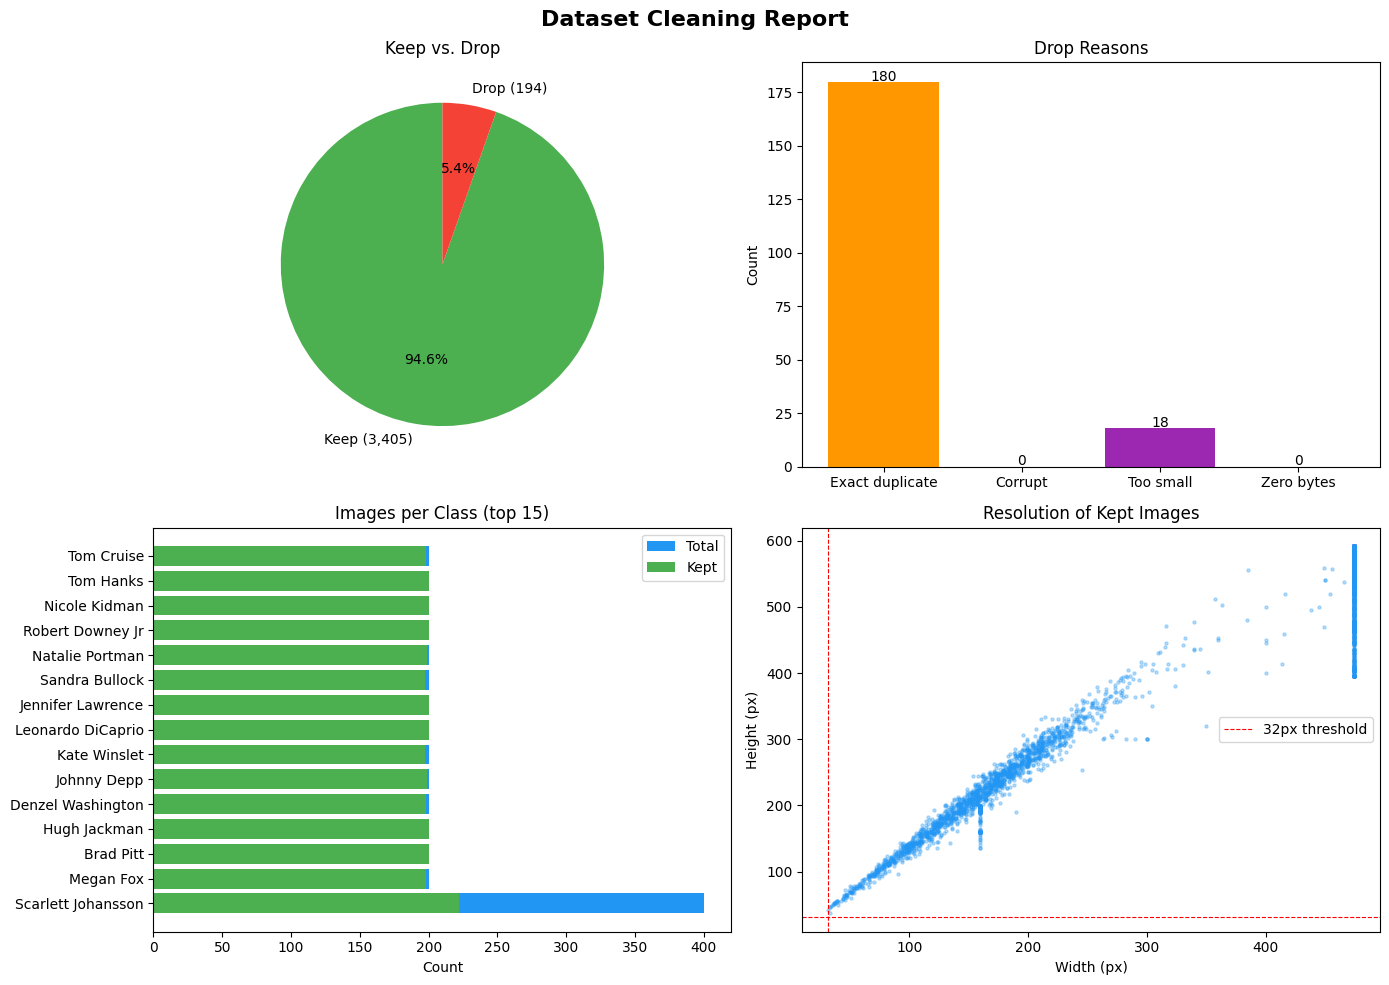


📈 Dashboard saved → /kaggle/working/cleaning_dashboard.png

CLEANING SUMMARY
Total images scanned  : 3,599
  ✅ To keep          : 3,405  (94.6%)
  ❌ To drop          : 194  (5.4%)
     • Exact dupes    : 180
     • Corrupt        : 0
     • Too small      : 18
     • Zero bytes     : 0
Classes (labels)      : 17

Next step: run copy_clean_dataset() below to materialise the cleaned set.

Copying 3,405 images to /kaggle/working/cleaned_dataset ...
Done ✅


In [7]:
import os
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict
from pathlib import Path
import shutil
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# CONFIG — adjust paths as needed
# ─────────────────────────────────────────────
DATASET_1 = '/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset'
DATASET_2 = '/kaggle/input/datasets/biyoukjabbarimanjili/processed-celebrity-face-image-dataset/processed_faces'
OUTPUT_DIR = '/kaggle/working/cleaned_dataset'
REPORT_PATH = '/kaggle/working/cleaning_report.csv'
SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# STEP 1: Collect all image paths from both datasets
# ─────────────────────────────────────────────
def collect_images(root: str) -> list[dict]:
    records = []
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if Path(fname).suffix.lower() in SUPPORTED_EXTS:
                full_path = os.path.join(dirpath, fname)
                # Infer class label from parent folder name
                label = os.path.basename(dirpath)
                records.append({
                    'path': full_path,
                    'filename': fname,
                    'label': label,
                    'source': root,
                    'size_bytes': os.path.getsize(full_path),
                })
    return records

print("📂 Scanning datasets...")
records1 = collect_images(DATASET_1)
records2 = collect_images(DATASET_2)
all_records = records1 + records2
df = pd.DataFrame(all_records)
print(f"  Dataset 1: {len(records1):,} images")
print(f"  Dataset 2: {len(records2):,} images")
print(f"  Total    : {len(df):,} images\n")

# ─────────────────────────────────────────────
# STEP 2: Compute MD5 hashes (exact duplicates)
# ─────────────────────────────────────────────
def md5_hash(path: str) -> str:
    h = hashlib.md5()
    try:
        with open(path, 'rb') as f:
            for chunk in iter(lambda: f.read(8192), b''):
                h.update(chunk)
        return h.hexdigest()
    except Exception:
        return 'ERROR'

print("🔍 Computing MD5 hashes for exact duplicate detection...")
df['md5'] = df['path'].apply(md5_hash)

exact_dupes = df[df['md5'] != 'ERROR'].groupby('md5').filter(lambda x: len(x) > 1)
n_exact_groups = exact_dupes['md5'].nunique()
print(f"  Exact duplicate groups  : {n_exact_groups}")
print(f"  Images that are dupes   : {len(exact_dupes):,}")

# Flag each row
df['is_exact_duplicate'] = df['md5'].isin(exact_dupes['md5'])
df['keep'] = True  # default — keep everything

# Mark all but the first occurrence as duplicates to drop
df.loc[df.duplicated(subset='md5', keep='first') & (df['md5'] != 'ERROR'), 'keep'] = False

# ─────────────────────────────────────────────
# STEP 3: Detect corrupt / unreadable images
# ─────────────────────────────────────────────
def check_image(path: str) -> dict:
    try:
        with Image.open(path) as img:
            img.verify()          # catches truncated files
        with Image.open(path) as img:
            w, h = img.size
            mode = img.mode
        return {'corrupt': False, 'width': w, 'height': h, 'mode': mode}
    except Exception as e:
        return {'corrupt': True, 'width': 0, 'height': 0, 'mode': 'UNKNOWN'}

print("\n🩺 Checking image integrity...")
health = df['path'].apply(check_image).apply(pd.Series)
df = pd.concat([df, health], axis=1)

n_corrupt = df['corrupt'].sum()
print(f"  Corrupt / unreadable    : {n_corrupt:,}")
df.loc[df['corrupt'], 'keep'] = False

# ─────────────────────────────────────────────
# STEP 4: Flag suspiciously small images
# ─────────────────────────────────────────────
MIN_DIM = 32          # pixels — anything smaller is likely garbage
df['too_small'] = (df['width'] < MIN_DIM) | (df['height'] < MIN_DIM)
n_small = df['too_small'].sum()
print(f"  Images < {MIN_DIM}px on a side: {n_small:,}")
df.loc[df['too_small'], 'keep'] = False

# ─────────────────────────────────────────────
# STEP 5: Flag zero-byte files
# ─────────────────────────────────────────────
df['zero_bytes'] = df['size_bytes'] == 0
n_zero = df['zero_bytes'].sum()
print(f"  Zero-byte files         : {n_zero:,}")
df.loc[df['zero_bytes'], 'keep'] = False

# ─────────────────────────────────────────────
# STEP 6: Cross-dataset duplicate summary
# ─────────────────────────────────────────────
print("\n📊 Cross-dataset duplicate analysis...")
cross = (
    exact_dupes
    .groupby('md5')['source']
    .apply(lambda s: 'cross-dataset' if s.nunique() > 1 else 'within-dataset')
    .value_counts()
)
print(cross.to_string())

# ─────────────────────────────────────────────
# STEP 7: Per-class statistics
# ─────────────────────────────────────────────
class_stats = df.groupby('label').agg(
    total=('path', 'count'),
    kept=('keep', 'sum'),
    duplicates=('is_exact_duplicate', 'sum'),
    corrupt=('corrupt', 'sum'),
    too_small=('too_small', 'sum'),
    avg_width=('width', 'mean'),
    avg_height=('height', 'mean'),
).reset_index().sort_values('total', ascending=False)

print(f"\n📋 Class breakdown (top 10):")
print(class_stats.head(10).to_string(index=False))

# ─────────────────────────────────────────────
# STEP 8: Save full report
# ─────────────────────────────────────────────
df.to_csv(REPORT_PATH, index=False)
print(f"\n💾 Full report saved → {REPORT_PATH}")
print(f"   Columns: {list(df.columns)}")

# ─────────────────────────────────────────────
# STEP 9: Summary dashboard
# ─────────────────────────────────────────────
total        = len(df)
kept         = df['keep'].sum()
dropped      = total - kept
pct_kept     = 100 * kept / total if total else 0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dataset Cleaning Report', fontsize=16, fontweight='bold')

# (a) Keep vs Drop pie
ax = axes[0, 0]
ax.pie(
    [kept, dropped],
    labels=[f'Keep ({kept:,})', f'Drop ({dropped:,})'],
    colors=['#4CAF50', '#F44336'],
    autopct='%1.1f%%', startangle=90,
)
ax.set_title('Keep vs. Drop')

# (b) Drop reasons bar
ax = axes[0, 1]
reasons = {
    'Exact duplicate': int((~df['keep'] & df['is_exact_duplicate']).sum()),
    'Corrupt':         int(n_corrupt),
    'Too small':       int(n_small),
    'Zero bytes':      int(n_zero),
}
ax.bar(reasons.keys(), reasons.values(), color=['#FF9800', '#F44336', '#9C27B0', '#607D8B'])
ax.set_title('Drop Reasons')
ax.set_ylabel('Count')
for i, (k, v) in enumerate(reasons.items()):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=10)

# (c) Images per class (top 15)
ax = axes[1, 0]
top15 = class_stats.nlargest(15, 'total')
bars = ax.barh(top15['label'], top15['total'], color='#2196F3', label='Total')
ax.barh(top15['label'], top15['kept'], color='#4CAF50', label='Kept')
ax.set_title('Images per Class (top 15)')
ax.set_xlabel('Count')
ax.legend()

# (d) Resolution scatter of kept images
ax = axes[1, 1]
kept_df = df[df['keep'] & ~df['corrupt']]
ax.scatter(kept_df['width'], kept_df['height'], alpha=0.3, s=5, color='#2196F3')
ax.set_title('Resolution of Kept Images')
ax.set_xlabel('Width (px)')
ax.set_ylabel('Height (px)')
ax.axhline(MIN_DIM, color='red', linestyle='--', linewidth=0.8, label=f'{MIN_DIM}px threshold')
ax.axvline(MIN_DIM, color='red', linestyle='--', linewidth=0.8)
ax.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/cleaning_dashboard.png', dpi=150)
plt.show()
print("\n📈 Dashboard saved → /kaggle/working/cleaning_dashboard.png")

# ─────────────────────────────────────────────
# STEP 10: Print final summary
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("CLEANING SUMMARY")
print("="*50)
print(f"Total images scanned  : {total:,}")
print(f"  ✅ To keep          : {kept:,}  ({pct_kept:.1f}%)")
print(f"  ❌ To drop          : {dropped:,}  ({100-pct_kept:.1f}%)")
print(f"     • Exact dupes    : {reasons['Exact duplicate']:,}")
print(f"     • Corrupt        : {reasons['Corrupt']:,}")
print(f"     • Too small      : {reasons['Too small']:,}")
print(f"     • Zero bytes     : {reasons['Zero bytes']:,}")
print(f"Classes (labels)      : {df['label'].nunique():,}")
print("="*50)
print("\nNext step: run copy_clean_dataset() below to materialise the cleaned set.")

# ─────────────────────────────────────────────
# OPTIONAL: Copy cleaned images to OUTPUT_DIR
# ─────────────────────────────────────────────
def copy_clean_dataset():
    """Copy every 'keep' image into OUTPUT_DIR/<label>/<filename>."""
    kept_df = df[df['keep']].copy()
    print(f"\nCopying {len(kept_df):,} images to {OUTPUT_DIR} ...")
    for _, row in kept_df.iterrows():
        dest_dir = os.path.join(OUTPUT_DIR, row['label'])
        os.makedirs(dest_dir, exist_ok=True)
        dest = os.path.join(dest_dir, row['filename'])
        # Avoid filename collision from two sources
        if os.path.exists(dest):
            stem = Path(row['filename']).stem
            ext  = Path(row['filename']).suffix
            dest = os.path.join(dest_dir, f"{stem}_2{ext}")
        shutil.copy2(row['path'], dest)
    print("Done ✅")

# Uncomment to run:
copy_clean_dataset()

STEP 1 — Class distribution audit

Total images : 3,422
Mean / class : 201  ±6
Max / Min    : 224 / 198  (imbalance ratio 1.1x)

Per-class counts:
Scarlett Johansson    224
Angelina Jolie        200
Brad Pitt             200
Jennifer Lawrence     200
Hugh Jackman          200
Leonardo DiCaprio     200
Kate Winslet          200
Megan Fox             200
Johnny Depp           200
Sandra Bullock        200
Natalie Portman       200
Robert Downey Jr      200
Nicole Kidman         200
Tom Hanks             200
Tom Cruise            200
Will Smith            200
Denzel Washington     198


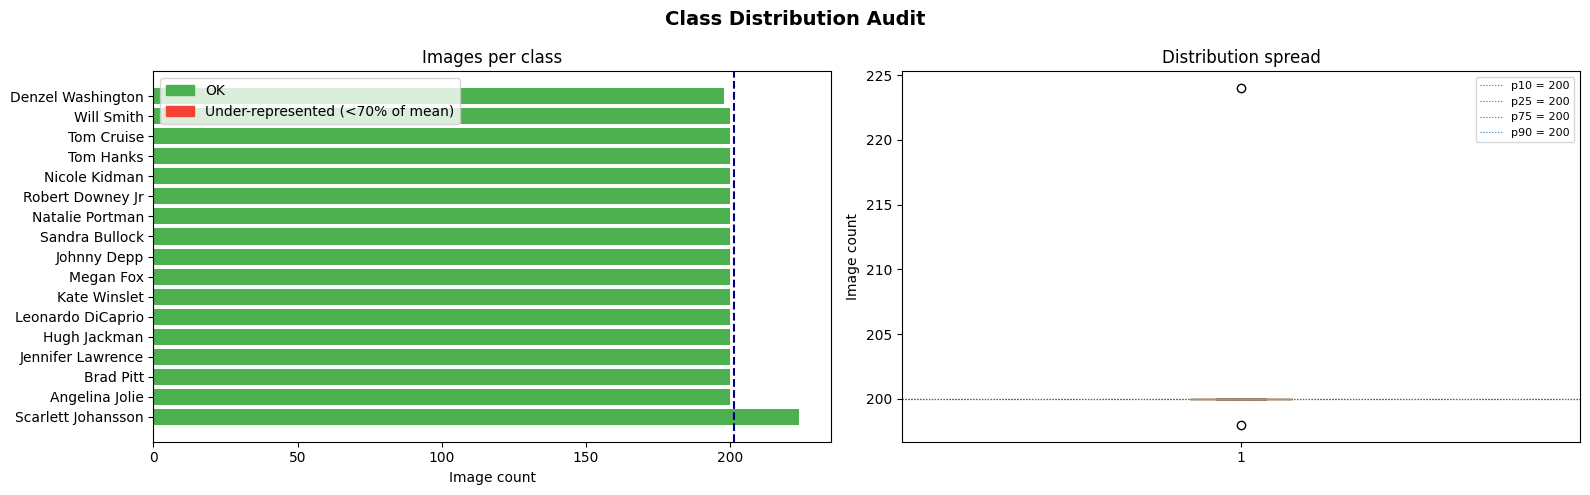


Saved → /kaggle/working/class_distribution.png


In [9]:
import matplotlib.patches as mpatches

DATASET_PATH='/kaggle/working/cleaned_dataset'
# ─────────────────────────────────────────────
# STEP 1: Class distribution audit
# ─────────────────────────────────────────────
print("=" * 55)
print("STEP 1 — Class distribution audit")
print("=" * 55)
 
class_counts = {}
for cls in sorted(os.listdir(DATASET_PATH)):
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        n = len([f for f in os.listdir(cls_path)
                 if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}])
        class_counts[cls] = n
 
counts_series = pd.Series(class_counts).sort_values(ascending=False)
total = counts_series.sum()
mean  = counts_series.mean()
std   = counts_series.std()
ratio = counts_series.max() / counts_series.min()
 
print(f"\nTotal images : {total:,}")
print(f"Mean / class : {mean:.0f}  ±{std:.0f}")
print(f"Max / Min    : {counts_series.max()} / {counts_series.min()}  "
      f"(imbalance ratio {ratio:.1f}x)")
print(f"\nPer-class counts:")
print(counts_series.to_string())
 
# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Class Distribution Audit', fontsize=14, fontweight='bold')
 
# Bar chart
colors = ['#F44336' if v < mean * 0.7 else '#4CAF50' for v in counts_series.values]
axes[0].barh(counts_series.index, counts_series.values, color=colors)
axes[0].axvline(mean, color='navy', linestyle='--', linewidth=1.5, label=f'Mean ({mean:.0f})')
axes[0].set_xlabel('Image count')
axes[0].set_title('Images per class')
axes[0].legend()
red_patch   = mpatches.Patch(color='#F44336', label='Under-represented (<70% of mean)')
green_patch = mpatches.Patch(color='#4CAF50', label='OK')
axes[0].legend(handles=[green_patch, red_patch])
 
# Box plot
axes[1].boxplot(counts_series.values, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#90CAF9'))
axes[1].set_ylabel('Image count')
axes[1].set_title('Distribution spread')
for pct, val in zip([10, 25, 75, 90],
                    np.percentile(counts_series.values, [10, 25, 75, 90])):
    axes[1].axhline(val, linestyle=':', linewidth=0.8,
                    label=f'p{pct} = {val:.0f}')
axes[1].legend(fontsize=8)
 
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=150)
plt.show()
print("\nSaved → /kaggle/working/class_distribution.png")
 

In [13]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = len(class_counts)
# ─── REBUILD GENERATORS (no rescale) ─────────────────────────────────────────
train_datagen = ImageDataGenerator(
    # NO rescale — EfficientNetB0 handles its own normalization internally
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,  # ← correct preprocessing
)

val_datagen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,  # ← same here
)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42,
    shuffle=True,
)

val_gen = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False,
)
print(f"\nTrain batches : {len(train_gen)}")
print(f"Val   batches : {len(val_gen)}")

Found 2739 images belonging to 17 classes.
Found 683 images belonging to 17 classes.

Train batches : 86
Val   batches : 22


## TEST ,TRSIN,VAL SPLIT AND LOAD AND TRAIN MODEL 

In [10]:
# ─── REBUILD GENERATORS (no rescale) ─────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = len(class_counts)
from sklearn.utils.class_weight import compute_class_weight

train_datagen = ImageDataGenerator(
    # NO rescale — EfficientNetB0 handles its own normalization internally
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,  # ← correct preprocessing
)

val_datagen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,  # ← same here
)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42,
    shuffle=True,
)

val_gen = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False,
)

# ─── STEP 6: BUILD MODEL ──────────────────────────────────────────────────────

base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax'),
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


# ─── Recompute class weights from the generator's true ordering ───────────────

from sklearn.utils.class_weight import compute_class_weight

class_names = [k for k, v in sorted(train_gen.class_indices.items(), key=lambda x: x[1])]
class_labels = np.array(train_gen.labels)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=class_labels,
)
class_weight_dict = dict(enumerate(weights))

print("Class weights:")
for i, name in enumerate(class_names):
    bar = '█' * int(weights[i] * 10)
    print(f"  [{i:2d}] {name:<25} {weights[i]:.3f}  {bar}")



# ─── STEP 7: PHASE 1 — frozen backbone ───────────────────────────────────────

callbacks = [
    keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        '/kaggle/working/best_model.keras',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1,
    ),
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,                         # give it more room before fine-tuning
    callbacks=callbacks,
    class_weight=class_weight_dict,    # ← don't forget this
)

# ─── STEP 8: PHASE 2 — fine-tune top layers ──────────────────────────────────

base_model.trainable = True
for layer in base_model.layers[:-30]:  # unfreeze slightly more than before
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=45,
    callbacks=callbacks,
    class_weight=class_weight_dict,    # ← keep here too
)

Found 2739 images belonging to 17 classes.
Found 683 images belonging to 17 classes.
Class weights:
  [ 0] Angelina Jolie            1.007  ██████████
  [ 1] Brad Pitt                 1.007  ██████████
  [ 2] Denzel Washington         1.013  ██████████
  [ 3] Hugh Jackman              1.007  ██████████
  [ 4] Jennifer Lawrence         1.007  ██████████
  [ 5] Johnny Depp               1.007  ██████████
  [ 6] Kate Winslet              1.007  ██████████
  [ 7] Leonardo DiCaprio         1.007  ██████████
  [ 8] Megan Fox                 1.007  ██████████
  [ 9] Natalie Portman           1.007  ██████████
  [10] Nicole Kidman             1.007  ██████████
  [11] Robert Downey Jr          1.007  ██████████
  [12] Sandra Bullock            1.007  ██████████
  [13] Scarlett Johansson        0.895  ████████
  [14] Tom Cruise                1.007  ██████████
  [15] Tom Hanks                 1.007  ██████████
  [16] Will Smith                1.007  ██████████
Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━

2026-05-12 17:09:32.641792: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 17:09:32.849649: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 17:09:33.310901: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 17:09:33.519380: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


68/86 ━━━━━━━━━━━━━━━━━━━━ 6s 364ms/step - accuracy: 0.4682 - loss: 1.7275

2026-05-12 17:10:13.145967: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 17:10:13.354946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 17:10:13.766018: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 17:10:13.976169: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.4641 - loss: 1.7280
Epoch 1: val_accuracy did not improve from 0.76720
86/86 ━━━━━━━━━━━━━━━━━━━━ 89s 694ms/step - accuracy: 0.4639 - loss: 1.7280 - val_accuracy: 0.6911 - val_loss: 0.8701 - learning_rate: 1.0000e-05
Epoch 2/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.4788 - loss: 1.6657
Epoch 2: val_accuracy did not improve from 0.76720
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 389ms/step - accuracy: 0.4788 - loss: 1.6655 - val_accuracy: 0.6794 - val_loss: 0.9154 - learning_rate: 1.0000e-05
Epoch 3/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.4913 - loss: 1.6085
Epoch 3: val_accuracy did not improve from 0.76720
86/86 ━━━━━━━━━━━━━━━━━━━━ 33s 384ms/step - accuracy: 0.4914 - loss: 1.6081 - val_accuracy: 0.6823 - val_loss: 0.9122 - learning_rate: 1.0000e-05
Epoch 4/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.5118 - loss: 1.5302
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.


In [13]:
# ─── STEP 8: PHASE 2 — fine-tune top layers ──────────────────────────────────

base_model.trainable = True
for layer in base_model.layers[:-30]:  # unfreeze slightly more than before
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weight_dict,    # ← keep here too
)

Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.6421 - loss: 1.0659
Epoch 1: val_accuracy improved from 0.76720 to 0.77013, saving model to /kaggle/working/best_model.keras
86/86 ━━━━━━━━━━━━━━━━━━━━ 89s 689ms/step - accuracy: 0.6420 - loss: 1.0661 - val_accuracy: 0.7701 - val_loss: 0.6583 - learning_rate: 1.0000e-05
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.6114 - loss: 1.1445
Epoch 2: val_accuracy improved from 0.77013 to 0.77452, saving model to /kaggle/working/best_model.keras
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 395ms/step - accuracy: 0.6116 - loss: 1.1441 - val_accuracy: 0.7745 - val_loss: 0.6448 - learning_rate: 1.0000e-05
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.6419 - loss: 1.0349
Epoch 3: val_accuracy improved from 0.77452 to 0.77599, saving model to /kaggle/working/best_model.keras
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 395ms/step - accuracy: 0.6419 - loss: 1.0351 - val_accuracy: 0.7760 - val_loss: 0.6359 - learning_rate: 

In [ ]:
# ─── STEP 8: PHASE 2 — fine-tune top layers ──────────────────────────────────

base_model.trainable = True
for layer in base_model.layers[:-30]:  # unfreeze slightly more than before
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight_dict,    # ← keep here too
)

Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.6894 - loss: 0.8920
Epoch 1: val_accuracy did not improve from 0.80381
86/86 ━━━━━━━━━━━━━━━━━━━━ 88s 692ms/step - accuracy: 0.6895 - loss: 0.8916 - val_accuracy: 0.8038 - val_loss: 0.5275 - learning_rate: 1.0000e-05
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.7105 - loss: 0.8850
Epoch 2: val_accuracy improved from 0.80381 to 0.80527, saving model to /kaggle/working/best_model.keras
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 397ms/step - accuracy: 0.7106 - loss: 0.8845 - val_accuracy: 0.8053 - val_loss: 0.5229 - learning_rate: 1.0000e-05
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.7280 - loss: 0.8172
Epoch 3: val_accuracy improved from 0.80527 to 0.80673, saving model to /kaggle/working/best_model.keras
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 400ms/step - accuracy: 0.7280 - loss: 0.8173 - val_accuracy: 0.8067 - val_loss: 0.5187 - learning_rate: 1.0000e-05
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 37

##  PLOT GRAPHS

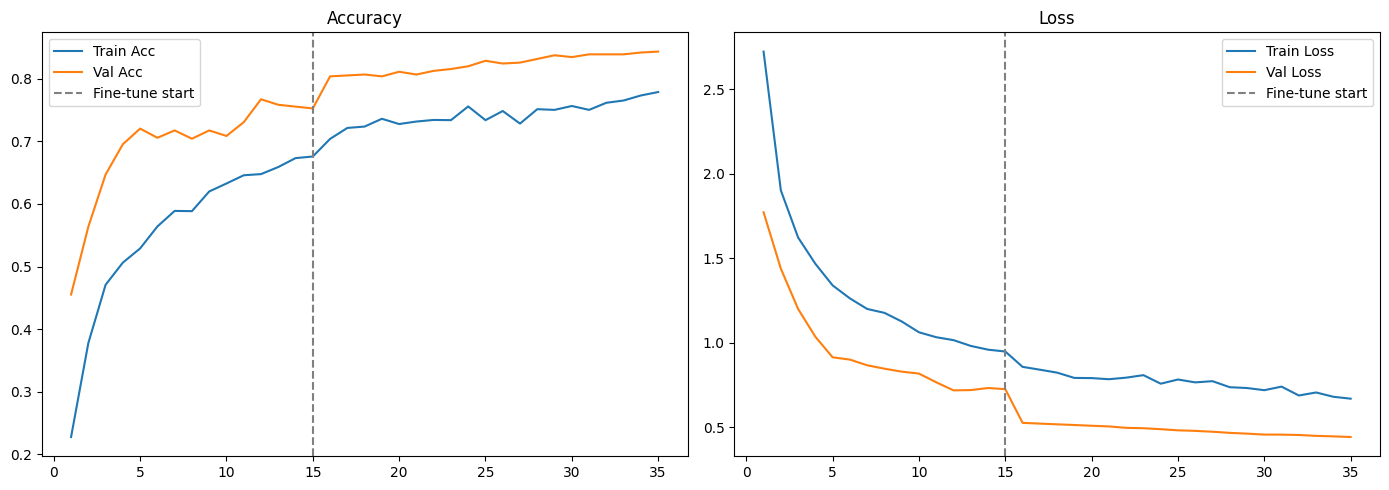


STEP 10 — Full Evaluation Metrics

Metric                            Score
----------------------------------------
Top-1 Accuracy                   0.8433
Top-3 Accuracy                   0.9795
Top-5 Accuracy                   0.9971
Precision (weighted)             0.8487
Recall (weighted)                0.8433
F1 Score (macro)                 0.8427
F1 Score (weighted)              0.8422

── Per-Class Report ──────────────────────────────────
                    precision    recall  f1-score   support

    Angelina Jolie      0.755     0.925     0.831        40
         Brad Pitt      0.810     0.850     0.829        40
 Denzel Washington      0.939     0.795     0.861        39
      Hugh Jackman      0.818     0.900     0.857        40
 Jennifer Lawrence      0.811     0.750     0.779        40
       Johnny Depp      0.975     0.975     0.975        40
      Kate Winslet      0.729     0.875     0.795        40
 Leonardo DiCaprio      0.857     0.900     0.878        40
      

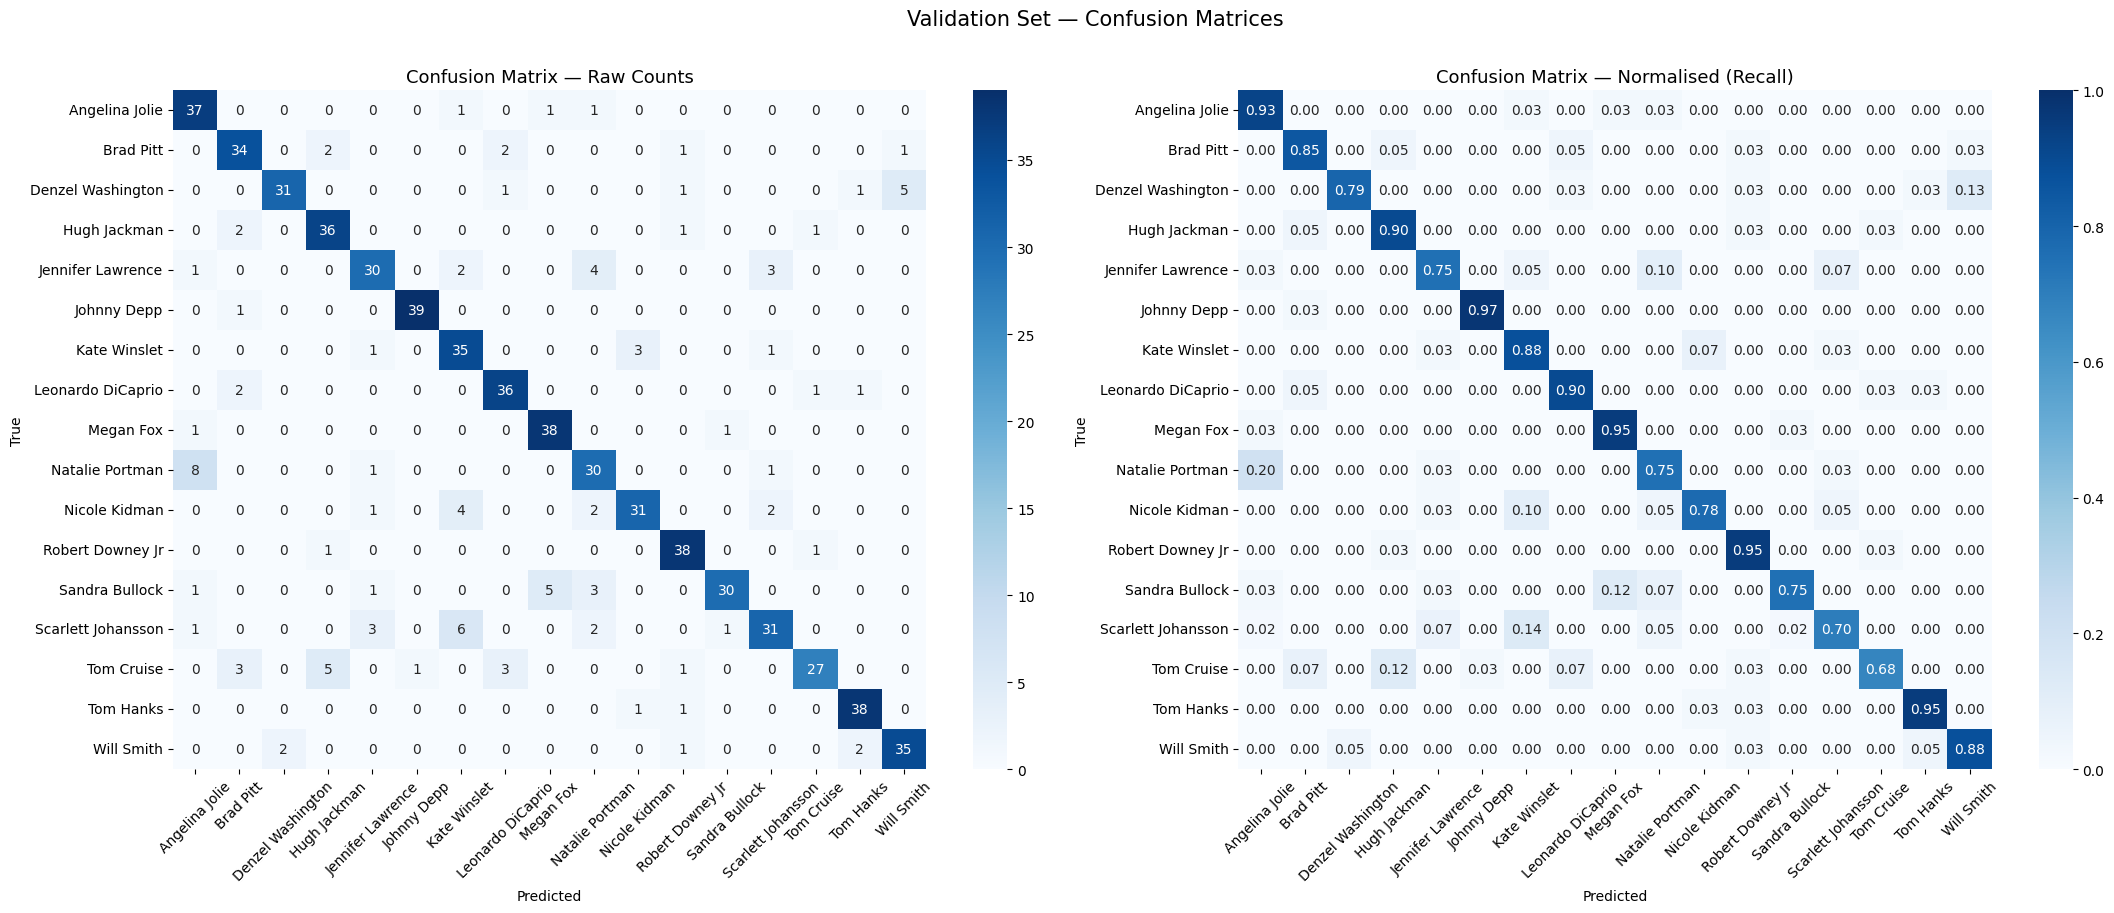

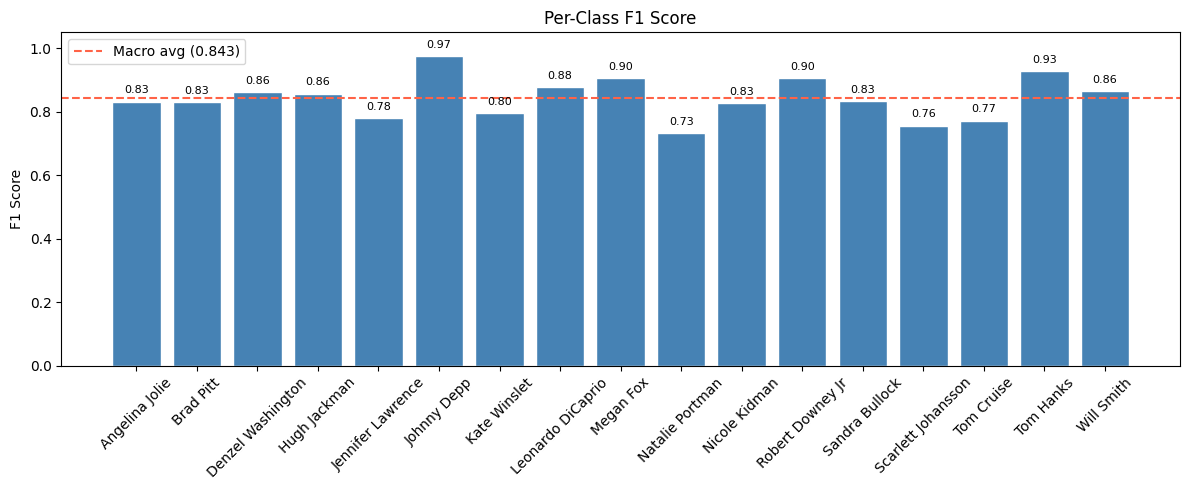


Done! Saved:
  /kaggle/working/best_model.keras
  /kaggle/working/label_map.json
  /kaggle/working/metrics.json
  /kaggle/working/training_curves.png
  /kaggle/working/confusion_matrix.png
  /kaggle/working/per_class_f1.png


In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, top_k_accuracy_score,
    precision_score, recall_score
)

# ─── PLOT TRAINING HISTORY ────────────────────────────────────────────────────

def plot_history(h1, h2):
    acc   = h1.history['accuracy']     + h2.history['accuracy']
    val   = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss  = h1.history['loss']         + h2.history['loss']
    vloss = h1.history['val_loss']     + h2.history['val_loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs       = range(1, len(acc) + 1)
    phase2_start = len(h1.history['accuracy'])

    ax1.plot(epochs, acc,  label='Train Acc')
    ax1.plot(epochs, val,  label='Val Acc')
    ax1.axvline(phase2_start, color='gray', linestyle='--', label='Fine-tune start')
    ax1.set_title('Accuracy'); ax1.legend()

    ax2.plot(epochs, loss,  label='Train Loss')
    ax2.plot(epochs, vloss, label='Val Loss')
    ax2.axvline(phase2_start, color='gray', linestyle='--', label='Fine-tune start')
    ax2.set_title('Loss'); ax2.legend()

    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png', dpi=150)
    plt.show()

plot_history(history1, history2)

# ─── STEP 10: EVALUATE ON VALIDATION SET ─────────────────────────────────────

print("\n" + "=" * 55)
print("STEP 10 — Full Evaluation Metrics")
print("=" * 55)

# Collect all predictions in one pass
val_gen.reset()
y_true, y_pred_probs = [], []

for i in range(len(val_gen)):
    X_batch, y_batch = val_gen[i]
    probs = model.predict(X_batch, verbose=0)
    y_pred_probs.append(probs)
    y_true.append(np.argmax(y_batch, axis=1))

y_true       = np.concatenate(y_true)
y_pred_probs = np.concatenate(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)

# ── Core scalar metrics ───────────────────────────────────────────────────────
acc_top1  = accuracy_score(y_true, y_pred)
acc_top3  = top_k_accuracy_score(y_true, y_pred_probs, k=3)
acc_top5  = top_k_accuracy_score(y_true, y_pred_probs, k=5)
f1_macro  = f1_score(y_true, y_pred, average='macro')
f1_weight = f1_score(y_true, y_pred, average='weighted')
prec      = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec       = recall_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n{'Metric':<30} {'Score':>8}")
print("-" * 40)
print(f"{'Top-1 Accuracy':<30} {acc_top1:>8.4f}")
print(f"{'Top-3 Accuracy':<30} {acc_top3:>8.4f}")
print(f"{'Top-5 Accuracy':<30} {acc_top5:>8.4f}")
print(f"{'Precision (weighted)':<30} {prec:>8.4f}")
print(f"{'Recall (weighted)':<30} {rec:>8.4f}")
print(f"{'F1 Score (macro)':<30} {f1_macro:>8.4f}")
print(f"{'F1 Score (weighted)':<30} {f1_weight:>8.4f}")

# ── Per-class report ──────────────────────────────────────────────────────────
print("\n── Per-Class Report ──────────────────────────────────")
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=3,
    zero_division=0,
))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Raw counts
sns.heatmap(
    cm, ax=axes[0],
    annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalised (recall per class on the diagonal)
sns.heatmap(
    cm_norm, ax=axes[1],
    annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
    xticklabels=class_names, yticklabels=class_names,
)
axes[1].set_title('Confusion Matrix — Normalised (Recall)', fontsize=13)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Validation Set — Confusion Matrices', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class F1 bar chart ────────────────────────────────────────────────────
per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_names, per_class_f1, color='steelblue', edgecolor='white')
ax.axhline(f1_macro, color='tomato', linestyle='--', linewidth=1.5, label=f'Macro avg ({f1_macro:.3f})')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score')
ax.tick_params(axis='x', rotation=45)
ax.legend()

# Annotate bars
for bar, score in zip(bars, per_class_f1):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{score:.2f}', ha='center', va='bottom', fontsize=8,
    )

plt.tight_layout()
plt.savefig('/kaggle/working/per_class_f1.png', dpi=150)
plt.show()

# ─── STEP 11: SAVE ARTEFACTS ─────────────────────────────────────────────────

label_map = {v: k for k, v in train_gen.class_indices.items()}
with open('/kaggle/working/label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)

metrics_summary = {
    "top1_accuracy":        round(acc_top1,  4),
    "top3_accuracy":        round(acc_top3,  4),
    "top5_accuracy":        round(acc_top5,  4),
    "precision_weighted":   round(prec,      4),
    "recall_weighted":      round(rec,       4),
    "f1_macro":             round(f1_macro,  4),
    "f1_weighted":          round(f1_weight, 4),
    "per_class_f1":         {name: round(float(s), 4)
                             for name, s in zip(class_names, per_class_f1)},
}
with open('/kaggle/working/metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print("\nDone! Saved:")
print("  /kaggle/working/best_model.keras")
print("  /kaggle/working/label_map.json")
print("  /kaggle/working/metrics.json")
print("  /kaggle/working/training_curves.png")
print("  /kaggle/working/confusion_matrix.png")
print("  /kaggle/working/per_class_f1.png")

In [17]:
git lfs install
git lfs track "*.keras"
git add .gitattributes
git add best_model.keras
git commit -m "add model weights via Git LFS"
git push

SyntaxError: invalid syntax (2959954467.py, line 1)